# Final Assignment Part 1
## Automobile Sales Analysis — Recession Impact
**XYZ Automotives | IBM Data Analysis with Python**

In [1]:
import requests
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import folium
import warnings
warnings.filterwarnings('ignore')

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"
response = requests.get(URL)
response.raise_for_status()
df = pd.read_csv(io.StringIO(response.text))
print('Data downloaded and read into a dataframe!')
print(df.shape)
df.head()

Data downloaded and read into a dataframe!
(2112, 15)


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


## 1.1 — Line Chart: Yearly Automobile Sales Fluctuation

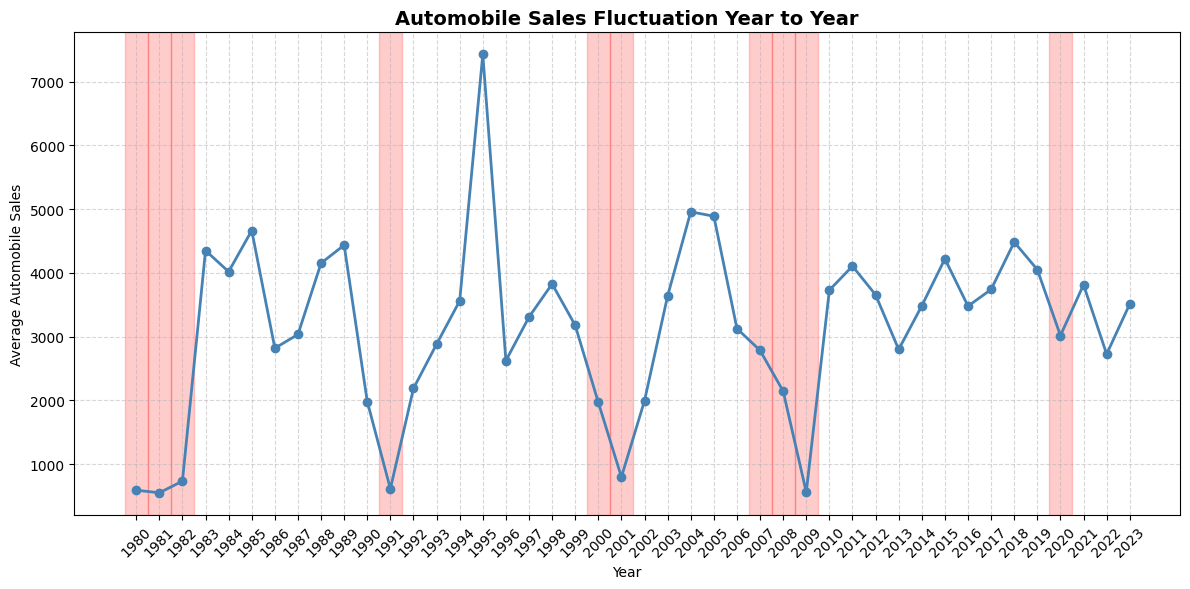

Chart 1.1 complete.


In [2]:
# 1.1: Line chart — automobile sales fluctuation year to year
yearly_sales = df.groupby('Year')['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(yearly_sales['Year'], yearly_sales['Automobile_Sales'],
         marker='o', color='steelblue', linewidth=2, markersize=6)

# Shade recession years
recession_years = df[df['Recession'] == 1]['Year'].unique()
for yr in recession_years:
    plt.axvspan(yr - 0.5, yr + 0.5, alpha=0.2, color='red', label='_nolegend_')

plt.title('Automobile Sales Fluctuation Year to Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.xticks(yearly_sales['Year'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_1_1_yearly_sales.png', dpi=150)
plt.show()
print("Chart 1.1 complete.")

## 1.2 — Line Chart: Advertising Expenditure vs Sales (Non-Recession)

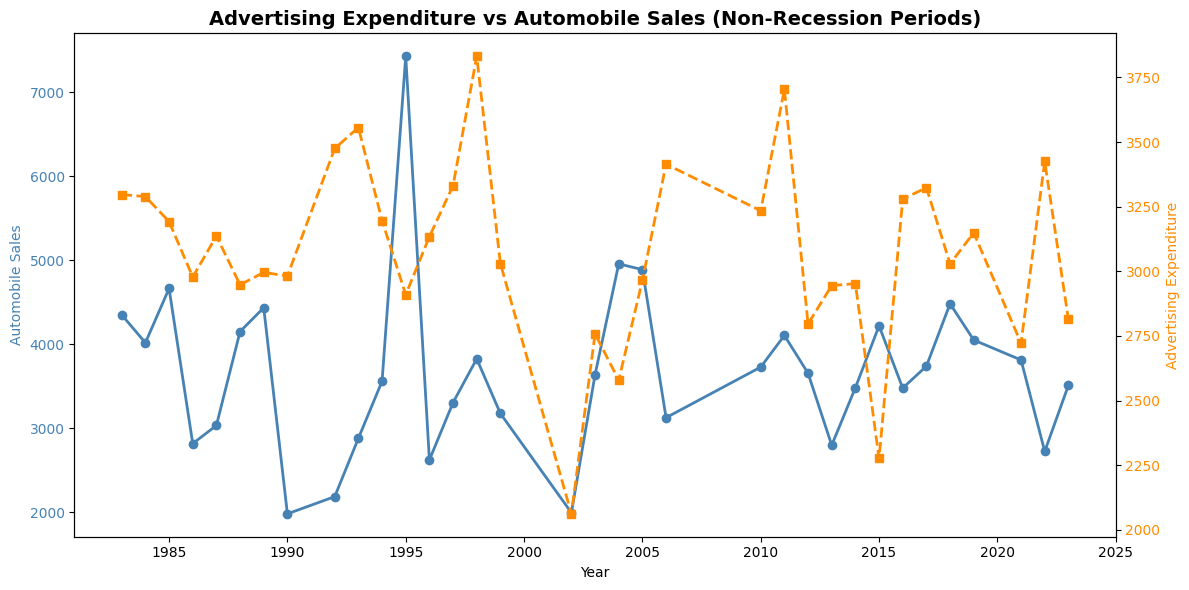

Chart 1.2 complete.


In [3]:
# 1.2: Advertising expenditure vs automobile sales during non-recession periods
non_recession = df[df['Recession'] == 0]
nr_yearly = non_recession.groupby('Year')[['Automobile_Sales', 'Advertising_Expenditure']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Year')
ax1.set_ylabel('Automobile Sales', color='steelblue')
ax1.plot(nr_yearly['Year'], nr_yearly['Automobile_Sales'],
         color='steelblue', marker='o', linewidth=2, label='Automobile Sales')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.set_ylabel('Advertising Expenditure', color='darkorange')
ax2.plot(nr_yearly['Year'], nr_yearly['Advertising_Expenditure'],
         color='darkorange', marker='s', linewidth=2, linestyle='--', label='Ad Expenditure')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Advertising Expenditure vs Automobile Sales (Non-Recession Periods)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('plot_1_2_ads_vs_sales.png', dpi=150)
plt.show()
print("Chart 1.2 complete.")

## 1.3 — Bar Chart: Sales per Vehicle Type — Recession vs Non-Recession

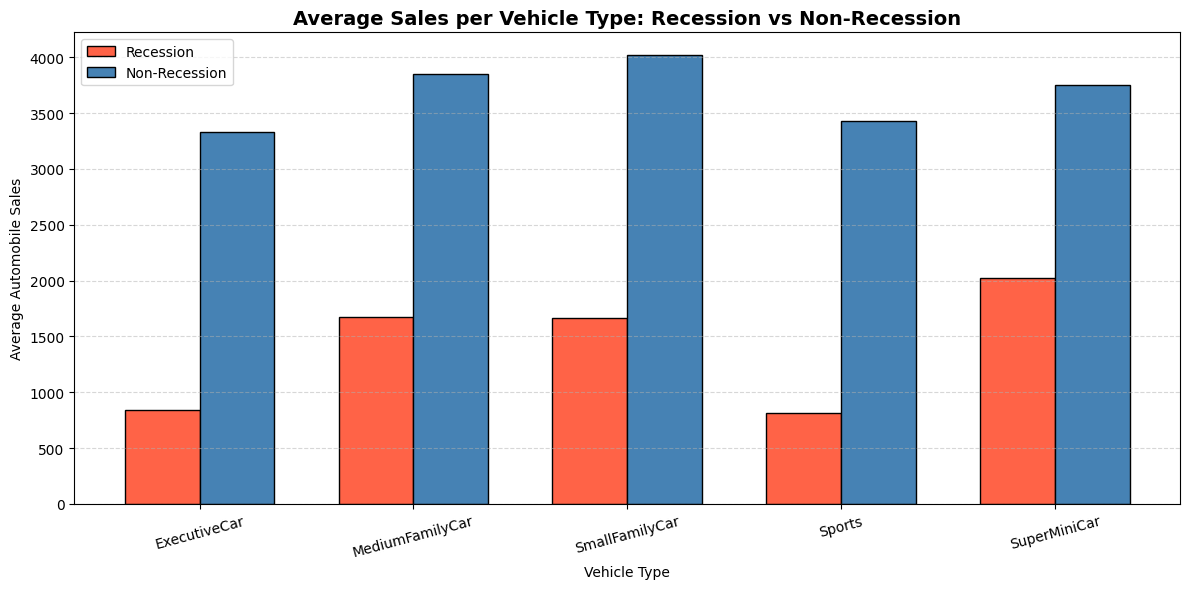

Chart 1.3 complete.


In [4]:
# 1.3: Bar chart — sales trend per vehicle type for recession vs non-recession
recession_vt = df[df['Recession'] == 1].groupby('Vehicle_Type')['Automobile_Sales'].mean()
non_recession_vt = df[df['Recession'] == 0].groupby('Vehicle_Type')['Automobile_Sales'].mean()

vehicle_types = recession_vt.index.tolist()
x = np.arange(len(vehicle_types))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, recession_vt.values, width, label='Recession', color='tomato', edgecolor='black')
bars2 = ax.bar(x + width/2, non_recession_vt.reindex(vehicle_types).values,
               width, label='Non-Recession', color='steelblue', edgecolor='black')

ax.set_xlabel('Vehicle Type')
ax.set_ylabel('Average Automobile Sales')
ax.set_title('Average Sales per Vehicle Type: Recession vs Non-Recession', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(vehicle_types, rotation=15)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_1_3_vehicle_type_bar.png', dpi=150)
plt.show()
print("Chart 1.3 complete.")

## 1.4 — Subplots: GDP Variation During Recession vs Non-Recession

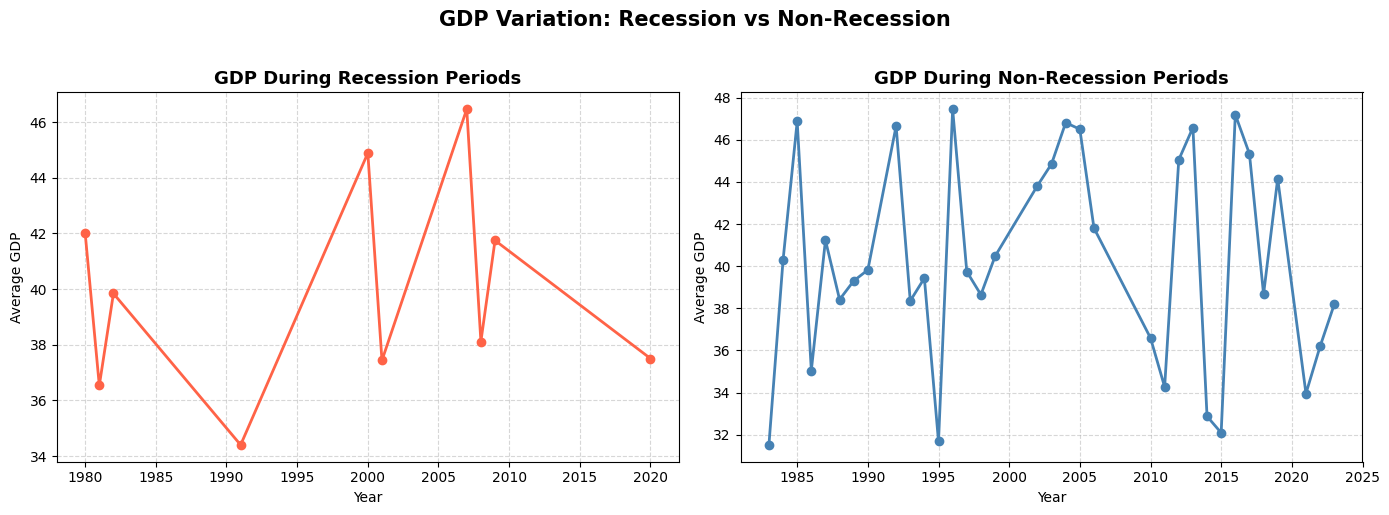

Chart 1.4 complete.


In [5]:
# 1.4: Subplots — GDP line plots for recession and non-recession periods
recession_gdp = df[df['Recession'] == 1].groupby('Year')['GDP'].mean().reset_index()
non_recession_gdp = df[df['Recession'] == 0].groupby('Year')['GDP'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recession_gdp['Year'], recession_gdp['GDP'],
             color='tomato', marker='o', linewidth=2)
axes[0].set_title('GDP During Recession Periods', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average GDP')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(non_recession_gdp['Year'], non_recession_gdp['GDP'],
             color='steelblue', marker='o', linewidth=2)
axes[1].set_title('GDP During Non-Recession Periods', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average GDP')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('GDP Variation: Recession vs Non-Recession', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_1_4_gdp_subplots.png', dpi=150)
plt.show()
print("Chart 1.4 complete.")

## 1.5 — Bubble Plot: Seasonality Impact on Automobile Sales

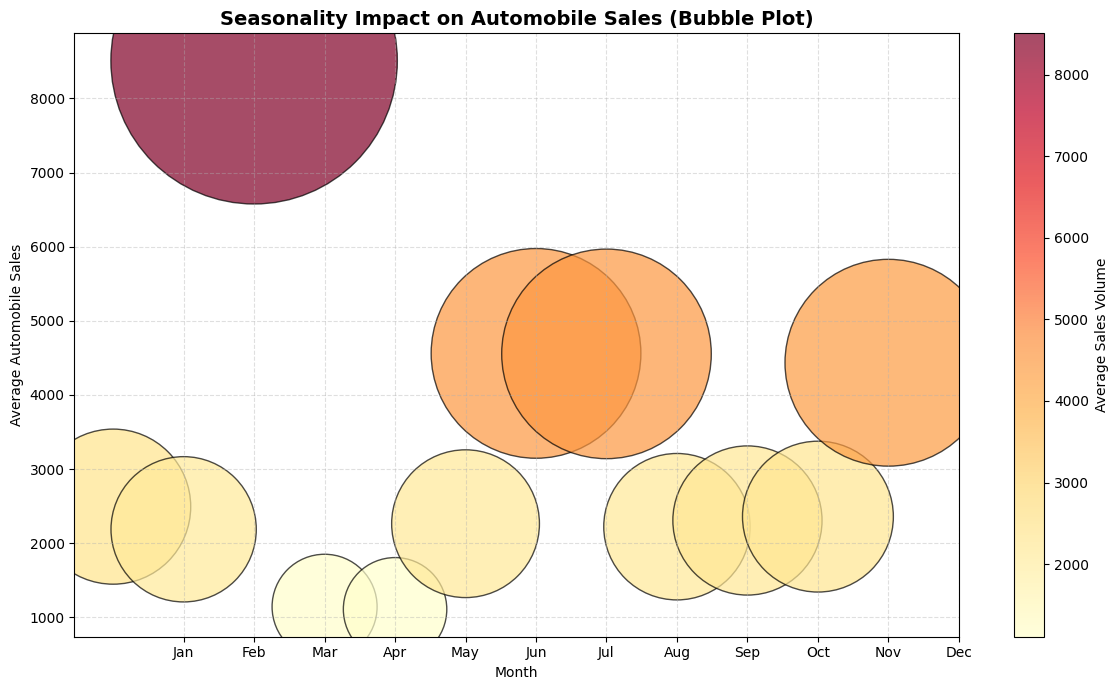

Chart 1.5 complete.


In [6]:
# 1.5: Bubble plot — seasonality impact on automobile sales
monthly_sales = df.groupby('Month').agg(
    Avg_Sales=('Automobile_Sales', 'mean'),
    Avg_Price=('Price', 'mean')
).reset_index()

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    monthly_sales['Month'],
    monthly_sales['Avg_Sales'],
    s=monthly_sales['Avg_Sales'] * 5,
    c=monthly_sales['Avg_Sales'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='black'
)

plt.colorbar(scatter, label='Average Sales Volume')
plt.title('Seasonality Impact on Automobile Sales (Bubble Plot)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Automobile Sales')
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.xticks(range(1, 13), month_labels)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('plot_1_5_seasonality_bubble.png', dpi=150)
plt.show()
print("Chart 1.5 complete.")

## 1.6 — Scatter Plot: Vehicle Price vs Sales Volume During Recession

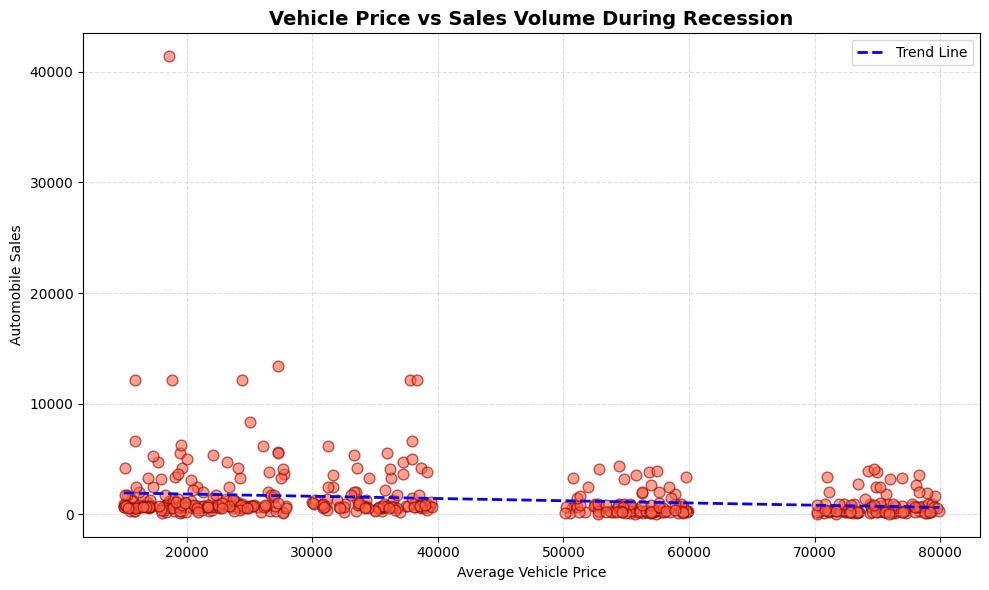

Chart 1.6 complete.


In [7]:
# 1.6: Scatter plot — average vehicle price vs sales volume during recession
recession_data = df[df['Recession'] == 1]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    recession_data['Price'],
    recession_data['Automobile_Sales'],
    c='tomato', alpha=0.6, edgecolors='darkred', s=60
)

# Add trend line
z = np.polyfit(recession_data['Price'], recession_data['Automobile_Sales'], 1)
p = np.poly1d(z)
x_line = np.linspace(recession_data['Price'].min(), recession_data['Price'].max(), 200)
plt.plot(x_line, p(x_line), 'b--', linewidth=2, label='Trend Line')

plt.title('Vehicle Price vs Sales Volume During Recession', fontsize=14, fontweight='bold')
plt.xlabel('Average Vehicle Price')
plt.ylabel('Automobile Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('plot_1_6_price_vs_sales_scatter.png', dpi=150)
plt.show()
print("Chart 1.6 complete.")

## 1.7 — Pie Chart: Ad Expenditure Share — Recession vs Non-Recession

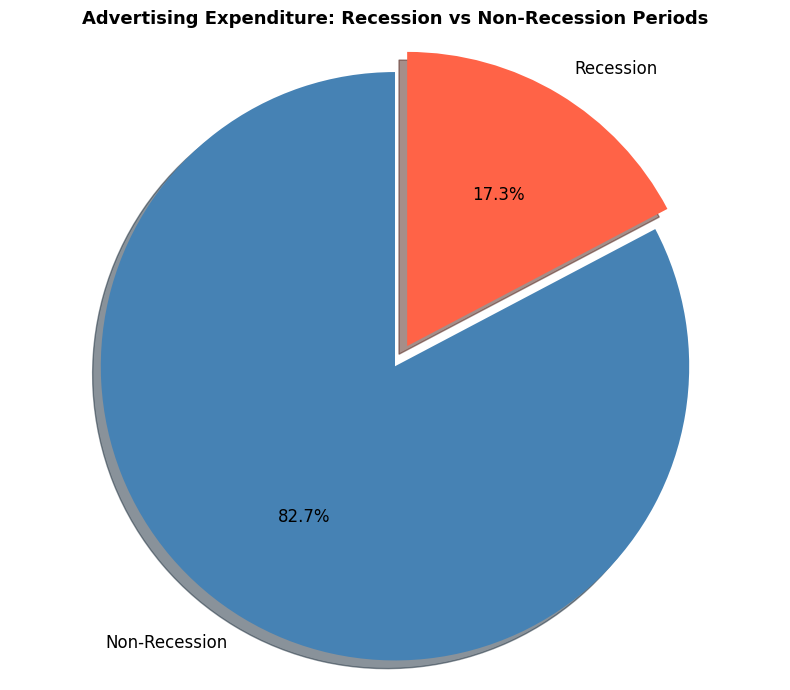

Chart 1.7 complete.


In [8]:
# 1.7: Pie chart — portion of advertising expenditure during recession vs non-recession
ad_exp = df.groupby('Recession')['Advertising_Expenditure'].sum()

labels = ['Non-Recession', 'Recession']
sizes = [ad_exp[0], ad_exp[1]]
colors = ['steelblue', 'tomato']
explode = (0, 0.08)

plt.figure(figsize=(8, 7))
plt.pie(sizes, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 12}, shadow=True)
plt.title('Advertising Expenditure: Recession vs Non-Recession Periods',
          fontsize=13, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig('plot_1_7_ad_pie_recession.png', dpi=150)
plt.show()
print("Chart 1.7 complete.")

## 1.8 — Pie Chart: Ad Expenditure per Vehicle Type During Recession

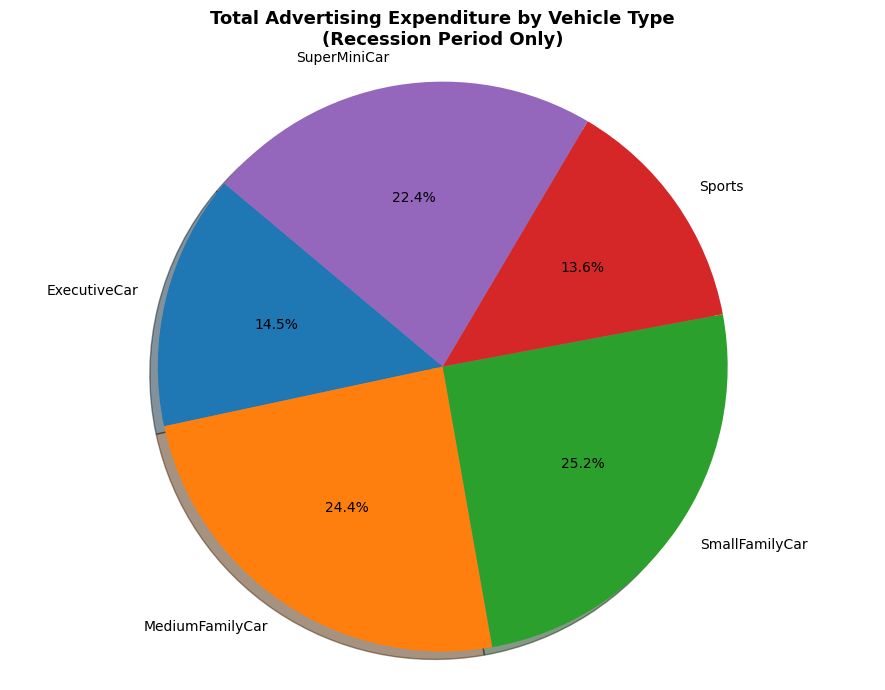

Chart 1.8 complete.


In [9]:
# 1.8: Pie chart — total ad expenditure per vehicle type during recession
recession_vt_ad = df[df['Recession'] == 1].groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(9, 7))
plt.pie(recession_vt_ad.values,
        labels=recession_vt_ad.index,
        autopct='%1.1f%%',
        startangle=140,
        textprops={'fontsize': 10},
        shadow=True)
plt.title('Total Advertising Expenditure by Vehicle Type\n(Recession Period Only)',
          fontsize=13, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig('plot_1_8_ad_pie_vehicle_type.png', dpi=150)
plt.show()
print("Chart 1.8 complete.")

## 1.9 — Line Chart: Unemployment Rate Effect on Vehicle Sales During Recession

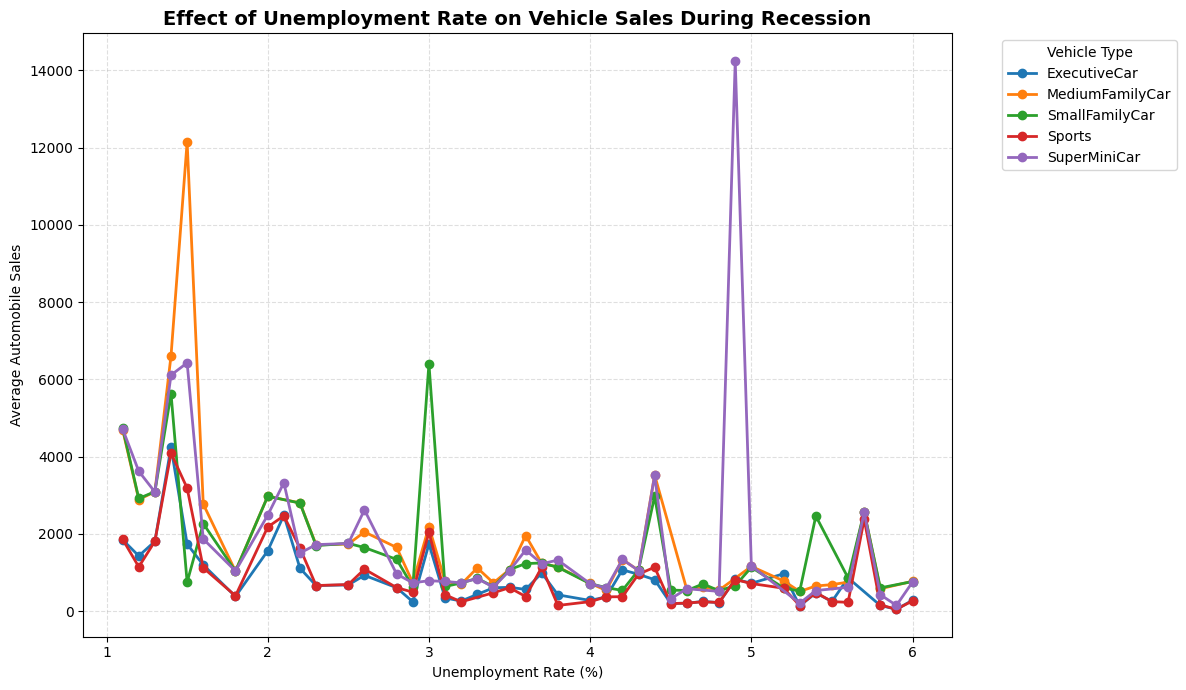

Chart 1.9 complete.


In [10]:
# 1.9: Line chart — unemployment rate vs vehicle type sales during recession
recession_unemployment = df[df['Recession'] == 1].groupby(
    ['unemployment_rate', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(12, 7))
for vtype in recession_unemployment['Vehicle_Type'].unique():
    subset = recession_unemployment[recession_unemployment['Vehicle_Type'] == vtype]
    subset_sorted = subset.sort_values('unemployment_rate')
    plt.plot(subset_sorted['unemployment_rate'], subset_sorted['Automobile_Sales'],
             marker='o', linewidth=2, label=vtype)

plt.title('Effect of Unemployment Rate on Vehicle Sales During Recession',
          fontsize=14, fontweight='bold')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Average Automobile Sales')
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('plot_1_9_unemployment_sales.png', dpi=150)
plt.show()
print("Chart 1.9 complete.")